In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
from functools import partial
import re

# Plotting
import matplotlib.pyplot as plt

In [2]:
# Define lat/lon ranges and region name for entire notebook
lat_start, lat_end = input("Enter latitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lat_range = (int(lat_start), int(lat_end))

lon_start, lon_end = input("Enter longitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lon_range = (int(lon_start), int(lon_end))

region = input("Which region do these ranges correspond to? If entire globe, enter nothing.")

In [3]:
def get_run_num(path):
    """
    function that extracts the exact number from the folder name so python won't sort it like 1, 10... but as 1, 2... 
    """
    # using regex to extract the number
    match = re.search(r'(\d+)$', path.name)
    # returning number as int (if match exists) --> this will help to sort it correctly 
    return int(match.group(1)) if match else 0

In [4]:
def load_nc_tryinglatlonrange(do_mean, abs_val, lat_range=lat_range, lon_range=lon_range):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments_50test" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*"), key=get_run_num):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder in sorted(folder_file_counts.keys(), key=get_run_num):
        count = folder_file_counts[run_folder]

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If lat, lon given are None ---------------------------------------
        # with no lat/lon ranges:
        if lat_range == (0,0) and lon_range == (0,0) :

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        else:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                # debug folder loading order
                print(f"folder: {run_folder.name}")
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':


            # debug folder loading order 
            print(f"folder: {run_folder.name}") 
            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data)

In [5]:
completeness_property_phi_matrix = load_nc_tryinglatlonrange(do_mean='no', abs_val='no')
print(completeness_property_phi_matrix.shape)

max is 56 files
folder: result_batchescarolinekranefuss_1
(1, 56, 25, 144, 73, 6)


In [6]:
parent_dir = Path.cwd() / "climate_experiments_50test"

#### **delta prediction calculation**

In [7]:
# initialize list that will hold the delta values
delta_data = []

# go thru the run folders --> track the index of the run folder
for run_idx, run_folder in enumerate(sorted(parent_dir.glob("result_batches*"), key=get_run_num)):
    print(f"processing run index {run_idx} (aka folder: {run_folder.name})")

    # go thru each file and track the file index 
    for file_idx, file in enumerate(sorted(list(run_folder.glob("*.nc")))):
        print(f"  -> processing file index {file_idx} (aka file: {file.name})")
        # open 
        ds = xr.open_dataset(file)
        # calculate the delta predictions (25 for each file)
        delta = (ds['y_pred'].values - ds['exact_baseline_prediction'].values)
        # print(delta.shape) # (25,)
    
        # go thru each sample idx and append to the id column
        for sample_idx in range(len(delta)):
            delta_data.append({
                'id': f"{run_idx}_{file_idx}_{sample_idx}",
                'delta': delta[sample_idx]
            })
        ds.close()

# make dataframe 
delta_df = pd.DataFrame(delta_data)

processing run index 0 (aka folder: result_batchescarolinekranefuss_1)
  -> processing file index 0 (aka file: res_ssp119_2015_2025.nc)
  -> processing file index 1 (aka file: res_ssp119_2015_2035.nc)
  -> processing file index 2 (aka file: res_ssp119_2015_2045.nc)
  -> processing file index 3 (aka file: res_ssp119_2015_2055.nc)
  -> processing file index 4 (aka file: res_ssp119_2015_2065.nc)
  -> processing file index 5 (aka file: res_ssp119_2015_2075.nc)
  -> processing file index 6 (aka file: res_ssp119_2015_2085.nc)
  -> processing file index 7 (aka file: res_ssp119_2025_2035.nc)
  -> processing file index 8 (aka file: res_ssp119_2025_2045.nc)
  -> processing file index 9 (aka file: res_ssp119_2025_2055.nc)
  -> processing file index 10 (aka file: res_ssp119_2025_2065.nc)
  -> processing file index 11 (aka file: res_ssp119_2025_2075.nc)
  -> processing file index 12 (aka file: res_ssp119_2025_2085.nc)
  -> processing file index 13 (aka file: res_ssp119_2035_2045.nc)
  -> processing

(array([ 10.,  13.,  17.,  43., 157., 438., 141., 125., 278., 178.]),
 array([-0.99954307, -0.80163997, -0.60373694, -0.40583384, -0.20793076,
        -0.01002768,  0.1878754 ,  0.38577849,  0.58368158,  0.78158462,
         0.97948772]),
 <BarContainer object of 10 artists>)

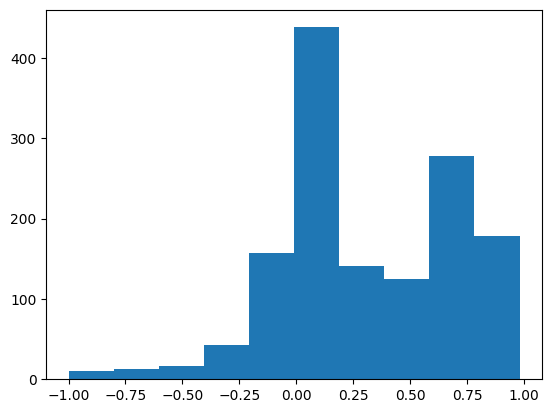

In [8]:
plt.hist(delta_df['delta'])

### **phi sum calculation**

In [9]:
# completeness property phi matrix --> (15, 56, 25, 144, 73, 6)
phi_data = []
# going thru each run batch (folder)
for r in range(completeness_property_phi_matrix.shape[0]):
    #print(f"processing run index {r}")

    # going thru each file in run batch
    for f in range(completeness_property_phi_matrix.shape[1]):
        #print(f"  -> processing file index {f}")

        # going thru each sample in file 
        for s in range(completeness_property_phi_matrix.shape[2]):
            #print(f"    -> processing sample index {s}")
            
            # sum over lat, lon, vars
            phi_val = np.sum(completeness_property_phi_matrix, axis=(3, 4, 5))

            # append to make df 
            phi_data.append({
                'id': f"{r}_{f}_{s}",
                'phi': phi_val
            })

phi_df = pd.DataFrame(phi_data)

In [10]:
merged = pd.merge(delta_df, phi_df, on='id')

In [11]:
print(f"Delta length: {len(delta_df)}")
print(f"Phi length: {len(phi_df)}")
print(f"Merged length: {len(merged)}")

Delta length: 1400
Phi length: 1400
Merged length: 1400


In [12]:
merged

,id,delta,phi
0,0_0_0,0.568110,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1,0_0_1,0.358435,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
2,0_0_2,0.616618,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
3,0_0_3,0.031626,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
4,0_0_4,0.511470,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
...,...,...,...
1395,0_55_20,0.093014,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1396,0_55_21,-0.163640,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1397,0_55_22,0.327203,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1398,0_55_23,0.188668,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."


In [13]:
len(merged['phi']) # 1 by 56 by 25

1400

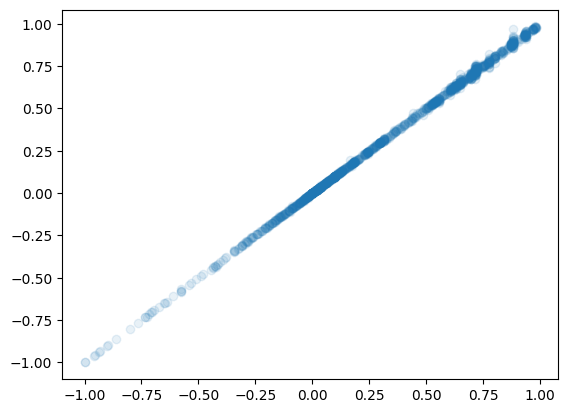

In [18]:
# 4. Now the scatter plot will be aligned regardless of processing order
plt.scatter(merged['delta'], merged['phi'][0], alpha=0.1)

**horizontal line** = no change in phi sum (0) but changes in pred delta --> vanishing gradient issue
    - because this is where the early & late years are super different so pred delta has values, but IG did not track feature importance bc vanishing gradient (?)

**vertical line at delta value of 0.00** = no change in pred delta (0) but changes in phi sum --> similar climate scenarios
    - predicted close to early period, causing 0.0 pred delta but IG picked up on feature differences (internal noise that IG picked up on?)

**vertical line at delta value of 1.00** = no change in pred delta (1) but changes in phi sum --> super different climate scenarios
    - delta pred perfectly predicted 1.0 (late period), but IG did not pick up on the same amount of feature importance bc jump was too big? 


In [15]:
merged

,id,delta,phi
0,0_0_0,0.568110,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1,0_0_1,0.358435,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
2,0_0_2,0.616618,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
3,0_0_3,0.031626,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
4,0_0_4,0.511470,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
...,...,...,...
1395,0_55_20,0.093014,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1396,0_55_21,-0.163640,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1397,0_55_22,0.327203,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."
1398,0_55_23,0.188668,"[[[0.5717133, 0.3647295, 0.63170886, 0.0403374..."


In [16]:
# looking at absolute error btwn delta and phi
merged['abs_error'] = (merged['delta'] - merged['phi']).abs()

sorted_df = merged.sort_values(by='abs_error', ascending=False)

sorted_df.head(10)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# calculating r2 and mae from scikit-learn
r2 = r2_score(merged['delta'], merged['phi'])
mae = mean_absolute_error(merged['delta'], merged['phi'])

print(f"r squared value: {r2:.4f}")
print(f"MAE: {mae:.4f}")

r squared value: 0.8555
MAE: 0.0537


In [ ]:
# threshold
epsilon = 0.05

# delta (x axis) close to 0 ish 
is_delta_zero = merged['delta'].abs() < epsilon

# look where phi is not 0 --> aka where the 1:1 points are 
is_phi_not_zero = merged['phi'].abs() > epsilon

# filter out merged df 
vertical_line_0 = merged[is_delta_zero & is_phi_not_zero]

vertical_line_0.head(10)

,id,delta,phi,abs_error
1267,0_50_17,-0.049615,-0.051541,0.001926
1413,1_0_13,0.048319,0.208022,0.159703
1436,1_1_11,-0.004887,-0.150696,0.145810
1601,1_8_1,0.016406,-0.232753,0.249159
1623,1_8_23,-0.003750,-0.131719,0.127969
1627,1_9_2,0.008022,0.118699,0.110677
1629,1_9_4,0.006708,-0.758931,0.765639
1630,1_9_5,0.008022,0.119324,0.111302
1631,1_9_6,0.007029,-0.740509,0.747538
1632,1_9_7,0.007458,-0.275875,0.283333


In [ ]:
# threshold
epsilon = 0.05

# delta (x axis) close to 1 ish 
is_delta_one = (merged['delta']-1.0).abs() < epsilon

# look where phi is not 1 --> aka where the 1:1 points are 
is_phi_not_one = merged['phi']< (1-epsilon)

# filter out merged df 
vertical_line_1 = merged[is_delta_one & is_phi_not_one]

vertical_line_1.head(10)

In [ ]:
# threshold
epsilon = 0.05

# phi (y axis) close to 0 ish 
is_phi_zero = merged['phi'].abs() < epsilon

# look where delta is not 0 --> aka where the 1:1 points are 
is_delta_not_zero = merged['delta'].abs() > epsilon

# filter out merged df 
horizontal_line_0 = merged[is_delta_zero & is_phi_not_zero]

horizontal_line_0.head(10)

In [ ]:
# 1. Isolate the Vertical Line (Phi Sum is ~0)
# We use a small threshold (1e-6) because floating point math rarely hits exactly 0.0
vertical_line_samples = merged[merged['phi'].abs() < 1e-6]

# 2. Isolate the Horizontal Line (Delta is ~0)
horizontal_line_samples = merged[merged['delta'].abs() < 1e-6]

# 3. Print a summary to see if they share common traits
print(f"Number of samples in Vertical Line: {len(vertical_line_samples)}")
print(f"Number of samples in Horizontal Line: {len(horizontal_line_samples)}")

# Optional: Inspect the first few to see if they are from the same Run/File
print("Sample of vertical line data:")
print(vertical_line_samples.head())

Number of samples in Vertical Line: 59
Number of samples in Horizontal Line: 10
Sample of vertical line data:
           id         delta           phi
1068  0_42_18  4.768372e-07 -1.785220e-07
3725   2_37_0  4.378974e-03  3.753791e-07
3726   2_37_1 -4.854697e-02  4.201497e-07
3727   2_37_2  4.492104e-03  4.277351e-07
3728   2_37_3  4.489243e-03  4.202994e-07


In [ ]:
vertical_line_samples

,id,delta,phi
1068,0_42_18,4.768372e-07,-1.785220e-07
3725,2_37_0,4.378974e-03,3.753791e-07
3726,2_37_1,-4.854697e-02,4.201497e-07
3727,2_37_2,4.492104e-03,4.277351e-07
3728,2_37_3,4.489243e-03,4.202994e-07
3729,2_37_4,3.775477e-03,3.751776e-07
3730,2_37_5,4.489839e-03,4.051331e-07
3731,2_37_6,4.278541e-03,4.237025e-07
3732,2_37_7,-9.615833e-01,3.694681e-07
3733,2_37_8,4.494965e-03,4.372142e-07


In [ ]:
horizontal_line_samples

,id,delta,phi
1068,0_42_18,4.768372e-07,-1.785220e-07
7677,5_27_2,0.000000e+00,0.000000e+00
7682,5_27_7,0.000000e+00,0.000000e+00
15175,10_47_0,0.000000e+00,0.000000e+00
15176,10_47_1,0.000000e+00,0.000000e+00
15182,10_47_7,0.000000e+00,0.000000e+00
15184,10_47_9,0.000000e+00,0.000000e+00
15188,10_47_13,0.000000e+00,0.000000e+00
15190,10_47_15,0.000000e+00,0.000000e+00
15194,10_47_19,0.000000e+00,0.000000e+00
